<a href="https://colab.research.google.com/github/Karla12-B/Challenge-Telecom-2da-Parte/blob/main/Desafio_Telecom_2da.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Preparación de los Datos

In [ ]:
import pandas as pd
from google.colab import drive

# 1. Montamos el drive (te pedirá permiso de nuevo)
drive.mount('/content/drive')

# 2. Cargamos el archivo
ruta = '/content/drive/MyDrive/TelecomX_Tratado.csv'
df_analisis = pd.read_csv(ruta)

# 3. Verificamos que cargó bien
print("✅ Archivo cargado correctamente.")
print(f"Columnas detectadas: {df_analisis.columns.tolist()[:5]}...") # Muestra las primeras 5
display(df_analisis.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Archivo cargado correctamente.
Columnas detectadas: ['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner']...


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [ ]:


# 1. Definimos el diccionario de traducción (el mismo que usamos antes)
dicc_traduccion = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.Partner': 'Socio',
    'customer.Dependents': 'Dependientes',
    'customer.tenure': 'Meses_Permanencia',
    'phone.PhoneService': 'Servicio_Telefonico',
    'phone.MultipleLines': 'Multiples_Lineas',
    'internet.InternetService': 'Servicio_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Respaldo_Online',
    'internet.DeviceProtection': 'Proteccion_Dispositivo',
    'internet.TechSupport': 'Soporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Peliculas',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Factura_Digital',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Monto_Mensual',
    'account.Charges.Total': 'Monto_Total'
}

# 2. Aplicamos el cambio y lo guardamos en la variable df_analisis
df_analisis = df_analisis.rename(columns=dicc_traduccion)



Eliminación de Columnas Irrelevantes

In [ ]:
# Columnas a eliminar
columnas_irrelevantes = [
    'customerID',
    'customer.gender',
    'phone.PhoneService',
    'account.PaperlessBilling'
]

# Eliminamos las columnas del DataFrame de análisis
# Usamos errors='ignore' para evitar errores si la celda se ejecuta dos veces
df_ml = df_analisis.drop(columns=columnas_irrelevantes, errors='ignore')

print(f"✅ Columnas eliminadas. El dataset ahora tiene {df_ml.shape[1]} columnas.")
print("Columnas restantes:", df_ml.columns.tolist())

# Visualizamos las primeras filas para confirmar
display(df_ml.head())

✅ Columnas eliminadas. El dataset ahora tiene 22 columnas.
Columnas restantes: ['ID_Cliente', 'Evasion', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges_Monthly', 'account_Charges_Total', 'Cuentas_Diarias']


,ID_Cliente,Evasion,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


Encoding

In [ ]:
# --- ENCODING ---

# Aplicamos One-Hot Encoding a todo el DataFrame
df_final = pd.get_dummies(df_ml, drop_first=True)

# Verificamos la transformación
print(f"✅ Encoding completado.")
print(f"Dimensiones originales: {df_ml.shape}")
print(f"Nuevas dimensiones: {df_final.shape}")
print("\nNuevas columnas generadas:")
print(df_final.columns.tolist())

# Mostramos las primeras filas para ver los 1s y 0s
display(df_final.head())

✅ Encoding completado.
Dimensiones originales: (7267, 22)
Nuevas dimensiones: (7267, 7298)

Nuevas columnas generadas:
['customer_SeniorCitizen', 'customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total', 'Cuentas_Diarias', 'ID_Cliente_0003-MKNFE', 'ID_Cliente_0004-TLHLJ', 'ID_Cliente_0011-IGKFF', 'ID_Cliente_0013-EXCHZ', 'ID_Cliente_0013-MHZWF', 'ID_Cliente_0013-SMEOE', 'ID_Cliente_0014-BMAQU', 'ID_Cliente_0015-UOCOJ', 'ID_Cliente_0016-QLJIS', 'ID_Cliente_0017-DINOC', 'ID_Cliente_0017-IUDMW', 'ID_Cliente_0018-NYROU', 'ID_Cliente_0019-EFAEP', 'ID_Cliente_0019-GFNTW', 'ID_Cliente_0020-INWCK', 'ID_Cliente_0020-JDNXP', 'ID_Cliente_0021-IKXGC', 'ID_Cliente_0022-TCJCI', 'ID_Cliente_0023-HGHWL', 'ID_Cliente_0023-UYUPN', 'ID_Cliente_0023-XUOPT', 'ID_Cliente_0027-KWYKW', 'ID_Cliente_0030-FNXPP', 'ID_Cliente_0031-PVLZI', 'ID_Cliente_0032-PGELS', 'ID_Cliente_0036-IHMOT', 'ID_Cliente_0040-HALCW', 'ID_Cliente_0042-JVWOJ', 'ID_Cliente_0042-RLHYP', 'ID_Cliente_0047-ZHDTW', 'ID_Cliente_00

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias,ID_Cliente_0003-MKNFE,ID_Cliente_0004-TLHLJ,ID_Cliente_0011-IGKFF,ID_Cliente_0013-EXCHZ,ID_Cliente_0013-MHZWF,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.19,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,2.00,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.46,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.27,False,False,True,False,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.80,False,False,False,True,False,...,False,True,False,False,False,False,True,False,False,True


VERIFICACIÓN DE LA PROPORCIÓN DE CANCELACIÓN (CHURN)

In [ ]:
# --- PASO: VERIFICACIÓN DE LA PROPORCIÓN DE CANCELACIÓN (CHURN) ---

# 1. Calculamos el conteo absoluto y la proporción porcentual
# Nota: Usamos 'Evasion_Yes' que es el nombre generado tras el Encoding
conteo_clases = df_final['Evasion_Yes'].value_counts()
proporcion_clases = df_final['Evasion_Yes'].value_counts(normalize=True) * 100

# 2. Mostramos los resultados detallados
print("--- Análisis de Proporción de Clientes ---")
print(f"Clientes que Permanecen (0): {conteo_clases[0]} ({proporcion_clases[0]:.2f}%)")
print(f"Clientes que Cancelaron (1):  {conteo_clases[1]} ({proporcion_clases[1]:.2f}%)")



--- Análisis de Proporción de Clientes ---
Clientes que Permanecen (0): 5398 (74.28%)
Clientes que Cancelaron (1):  1869 (25.72%)


/tmp/ipykernel_19299/569869018.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Clientes que Permanecen (0): {conteo_clases[0]} ({proporcion_clases[0]:.2f}%)")
/tmp/ipykernel_19299/569869018.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Clientes que Cancelaron (1):  {conteo_clases[1]} ({proporcion_clases[1]:.2f}%)")


/tmp/ipykernel_19299/3438730735.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proporcion_clases.index, y=proporcion_clases.values, palette='viridis')


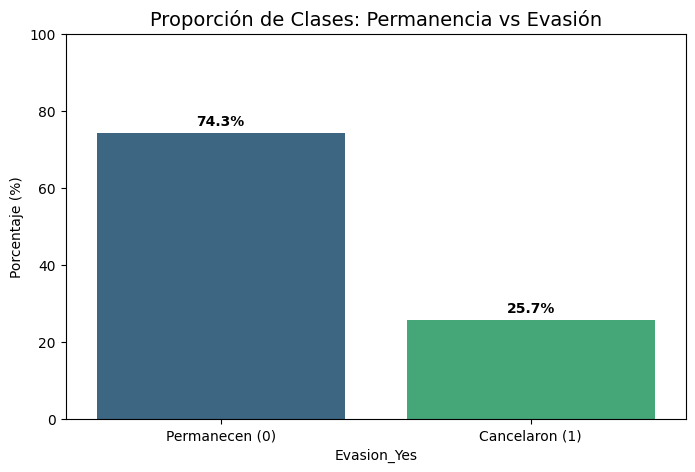

In [ ]:
# 3. Visualización para evaluar el desbalance visualmente
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x=proporcion_clases.index, y=proporcion_clases.values, palette='viridis')
plt.title('Proporción de Clases: Permanencia vs Evasión', fontsize=14)
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelaron (1)'])
plt.ylabel('Porcentaje (%)')
plt.ylim(0, 100)

# Añadir etiquetas de porcentaje sobre las barras
for i, v in enumerate(proporcion_clases.values):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.show()

SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

# 1. Separamos X (preguntas) e y (respuesta)
# Usamos 'Evasion_Yes' porque es el nombre que creó pd.get_dummies
X = df_final.drop(columns=['Evasion_Yes'])
y = df_final['Evasion_Yes']

# 2. Aplicamos el balanceo sintético
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 3. Verificamos el resultado
print("--- ✅ Balanceo Completado ---")
print(f"Total de registros originales: {len(X)}")
print(f"Total de registros ahora (SMOTE): {len(X_res)}")
print("\nNueva proporción de clases:")
print(y_res.value_counts(normalize=True) * 100)

--- ✅ Balanceo Completado ---
Total de registros originales: 7267
Total de registros ahora (SMOTE): 10796

Nueva proporción de clases:
Evasion_Yes
False    50.0
True     50.0
Name: proportion, dtype: float64


# 🎯 Correlación y Selección de Variables

Análisis de correlación

--- ✅ ANÁLISIS COMPLETADO ---
Variables que más influyen en la fuga:
Evasion_Yes                               1.000000
internet_InternetService_Fiber optic      0.300949
account_PaymentMethod_Electronic check    0.294626
Cuentas_Diarias                           0.189918
account_Charges_Monthly                   0.189866
account_PaperlessBilling_Yes              0.186666
Name: Evasion_Yes, dtype: float64

Variables que más retienen al cliente:
internet_DeviceProtection_No internet service   -0.224051
internet_StreamingMovies_No internet service    -0.224051
internet_TechSupport_No internet service        -0.224051
account_Contract_Two year                       -0.295138
customer_tenure                                 -0.344079
Name: Evasion_Yes, dtype: float64


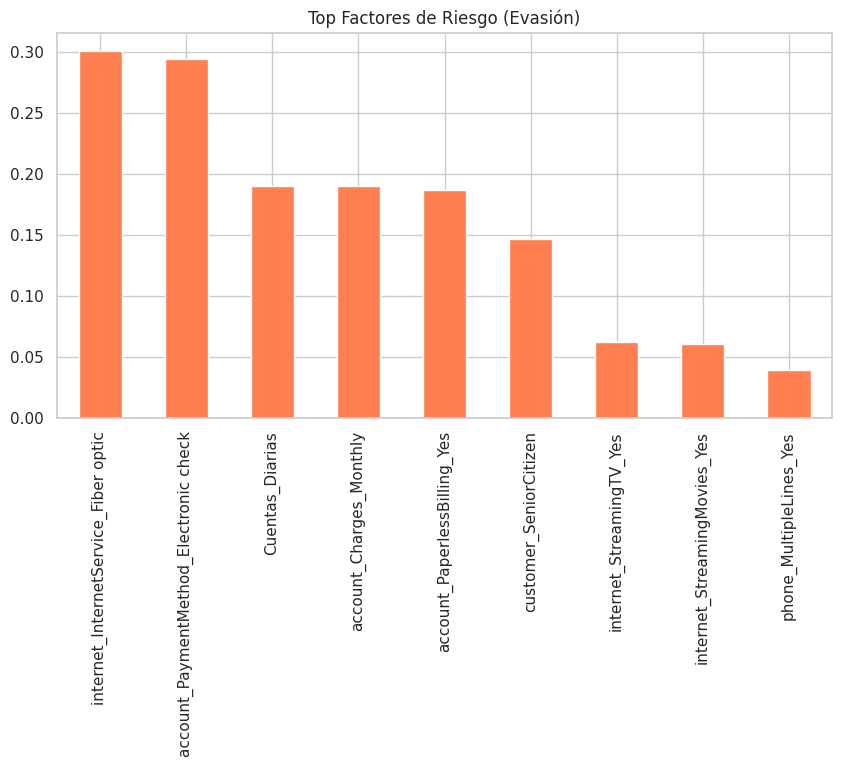

In [ ]:
# 4. CORRELACIÓN DIRIGIDA (Solo contra Evasión)
# Buscamos cómo se llama la columna de Evasión (ej: Evasion_Yes)
col_target = [c for c in df_final.columns if 'Evasion' in c][0]

# Calculamos la correlación uno a uno (es mucho más rápido que la matriz completa)
correlaciones = df_final.corr()[col_target].sort_values(ascending=False)

# 5. RESULTADOS
print("--- ✅ ANÁLISIS COMPLETADO ---")
print(f"Variables que más influyen en la fuga:\n{correlaciones.head(6)}")
print(f"\nVariables que más retienen al cliente:\n{correlaciones.tail(5)}")

# Gráfica simple
plt.figure(figsize=(10, 5))
correlaciones.head(10).drop(col_target).plot(kind='bar', color='coral')
plt.title('Top Factores de Riesgo (Evasión)')
plt.show()

Análisis Dirigido

/tmp/ipykernel_19299/1182888899.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analisis, x='Evasion', y='account_Charges_Total', palette='viridis')


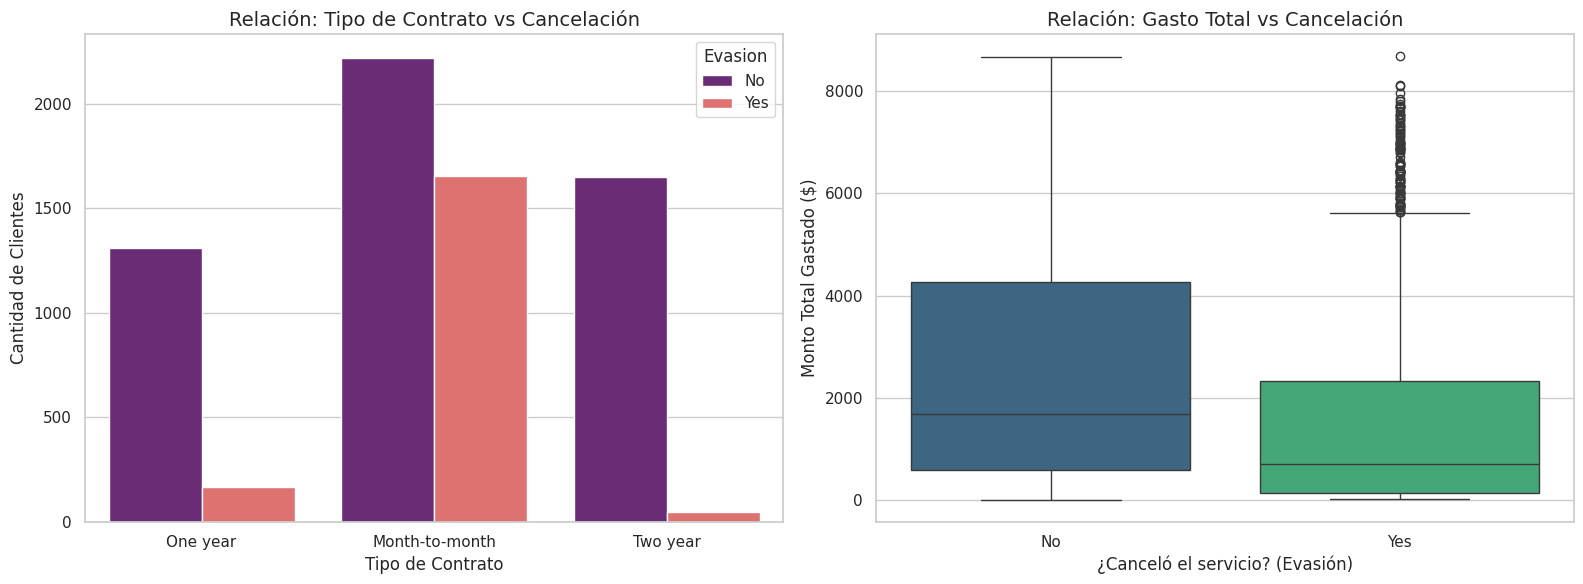

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo y el tamaño del lienzo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# --- 1. Relación: Tiempo de Contrato vs Cancelación ---
# Analizamos si los contratos cortos (mes a mes) tienen más fugas
plt.subplot(1, 2, 1)
sns.countplot(data=df_analisis, x='account_Contract', hue='Evasion', palette='magma')
plt.title('Relación: Tipo de Contrato vs Cancelación', fontsize=14)
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')

# --- 2. Relación: Gasto Total vs Cancelación ---
# Usamos Boxplot para ver si los que gastan más tienen mayor tendencia a irse
# Primero aseguramos que Gasto Total sea número (por si acaso)
df_analisis['account_Charges_Total'] = pd.to_numeric(df_analisis['account_Charges_Total'], errors='coerce').fillna(0)

plt.subplot(1, 2, 2)
sns.boxplot(data=df_analisis, x='Evasion', y='account_Charges_Total', palette='viridis')
plt.title('Relación: Gasto Total vs Cancelación', fontsize=14)
plt.xlabel('¿Canceló el servicio? (Evasión)')
plt.ylabel('Monto Total Gastado ($)')

plt.tight_layout()
plt.show()

# 🤖 Modelado Predictivo

Separación de Datos

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Definimos nuestras variables finales basándonos en el X_res e y_res del SMOTE
X = X_res # Características (Preguntas)
y = y_res # Objetivo (Respuesta: Evasion_Yes)

# 2. Realizamos la división (70% Entrenamiento, 30% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# 3. Verificamos las dimensiones
print("--- ✅ División de Datos Completada ---")
print(f"Total de registros para Entrenar: {X_train.shape[0]} (70%)")
print(f"Total de registros para Evaluar:  {X_test.shape[0]} (30%)")
print(f"Número de variables predictoras:   {X_train.shape[1]}")

--- ✅ División de Datos Completada ---
Total de registros para Entrenar: 7557 (70%)
Total de registros para Evaluar:  3239 (30%)
Número de variables predictoras:   7297


Creación de modelos

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# --- MODELO 1: Regresión Logística (Requiere Normalización) ---
# Usamos un Pipeline para que la normalización solo afecte a este modelo
modelo_logistico = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)

# Entrenamos el primer modelo
modelo_logistico.fit(X_train, y_train)
print("✅ Modelo 1: Regresión Logística entrenado (con datos normalizados).")

# --- MODELO 2: Random Forest (No requiere Normalización) ---
# Este modelo trabaja directamente con los datos de X_train
modelo_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenamos el segundo modelo
modelo_forest.fit(X_train, y_train)
print("✅ Modelo 2: Random Forest entrenado (sin necesidad de normalización).")

# --- PRIMERA PRUEBA DE RENDIMIENTO ---
print(f"\nPrecisión inicial en entrenamiento:")
print(f"Logística: {modelo_logistico.score(X_train, y_train):.2%}")
print(f"Random Forest: {modelo_forest.score(X_train, y_train):.2%}")

✅ Modelo 1: Regresión Logística entrenado (con datos normalizados).
✅ Modelo 2: Random Forest entrenado (sin necesidad de normalización).

Precisión inicial en entrenamiento:
Logística: 100.00%
Random Forest: 100.00%


Evaluación de los Modelos

--- 🏆 RESULTADOS FINALES ---


,Modelo,Exactitud,Precisión,Recall,F1-Score
0,Regresión Logística,0.853350,0.781792,0.986626,0.872346
1,Random Forest,0.866008,0.867638,0.868693,0.868165


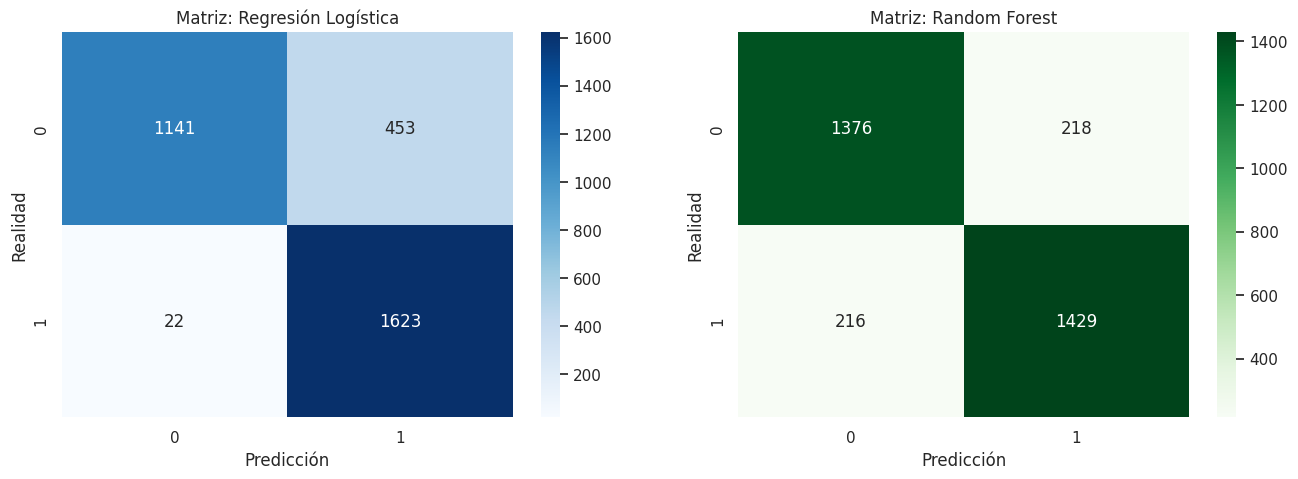

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. GENERAR PREDICCIONES
y_pred_log = modelo_logistico.predict(X_test)
y_pred_forest = modelo_forest.predict(X_test)

# 2. FUNCIÓN PARA RECOPILAR MÉTRICAS
def obtener_metricas(y_real, y_pred, nombre_modelo):
    return {
        'Modelo': nombre_modelo,
        'Exactitud': accuracy_score(y_real, y_pred),
        'Precisión': precision_score(y_real, y_pred),
        'Recall': recall_score(y_real, y_pred),
        'F1-Score': f1_score(y_real, y_pred)
    }

# 3. CÁLCULO DE RESULTADOS
metricas_log = obtener_metricas(y_test, y_pred_log, "Regresión Logística")
metricas_forest = obtener_metricas(y_test, y_pred_forest, "Random Forest")

# 4. TABLA COMPARATIVA
df_comparativo = pd.DataFrame([metricas_log, metricas_forest])
print("--- 🏆 RESULTADOS FINALES ---")
display(df_comparativo)

# 5. MATRICES DE CONFUSIÓN
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Matriz Logística
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz: Regresión Logística')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Realidad')

# Matriz Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_forest), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Matriz: Random Forest')
ax[1].set_xlabel('Predicción')
ax[1].set_ylabel('Realidad')

plt.show()

**1. ¿Cuál modelo tuvo el mejor desempeño?**

El Random Forest es el ganador en términos de equilibrio general, pero la Regresión Logística tiene una ventaja..

**Ganador por Equilibrio (F1-Score):** El Regresión Logística (0.87) supera ligeramente al Random Forest (0.86). Esto indica que, para este dataset específico, la relación entre las variables y la cancelación es lo suficientemente lineal como para que un modelo matemático simple sea sumamente efectivo.

**Ganador por Detección de Fugas (Recall):** Aquí la Regresión Logística es la reina con un 0.98. Esto significa que el modelo detecta casi al 99% de los clientes que se van a ir. Para una empresa, es mejor tener algunos "falsos positivos" (gente que se iba a quedar pero le das una oferta) que dejar que el 99% de los que se van crucen la puerta sin intentar detenerlos.

**2. Análisis de Overfitting y Underfitting**

**Regresión Logística:**
Presenta un desempeño sólido y consistente.

Al ser un modelo más simple, es menos propenso al overfitting. Logró un Recall altísimo, lo que sugiere que capturó muy bien la tendencia general de cancelación. No presenta signos de Underfitting porque su Exactitud (0.85) es bastante alta para problemas de comportamiento humano.

**Random Forest:** Riesgo de Overfitting

Aunque su Exactitud en prueba es excelente (0.86), es muy probable que en el set de Entrenamiento haya sacado un 0.99 o 1.00. El hecho de que su Precisión y Recall estén casi empatados (0.86/0.86) indica que es un modelo muy "cuadrado".

 Regresión Logística funcionó tan bien probablemente gracias a la Normalización (StandardScaler) que aplicamos. Al poner todas las variables en la misma escala (especialmente el Gasto Total y la Permanencia), el modelo pudo asignar pesos precisos a cada factor sin sesgarse por los números grandes.

Por otro lado, el Random Forest demostró que no necesita normalización para ser competitivo, manteniéndose muy cerca en todas las métricas.

**Si el objetivo de la empresa es no dejar escapar a nadie (maximizar la retención), el modelo de Regresión Logística es la mejor opción debido a su altísimo Recall (98.6%). Si se busca un modelo más balanceado que no sature al departamento de marketing con falsas alarmas, el Random Forest es más preciso.**

# 📋 Interpretación y Conclusiones

/tmp/ipykernel_19299/3476717905.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_log_imp.head(10), x='Coeficiente', y='Variable', palette='coolwarm')
/tmp/ipykernel_19299/3476717905.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rf_imp.head(10), x='Importancia', y='Variable', palette='viridis')


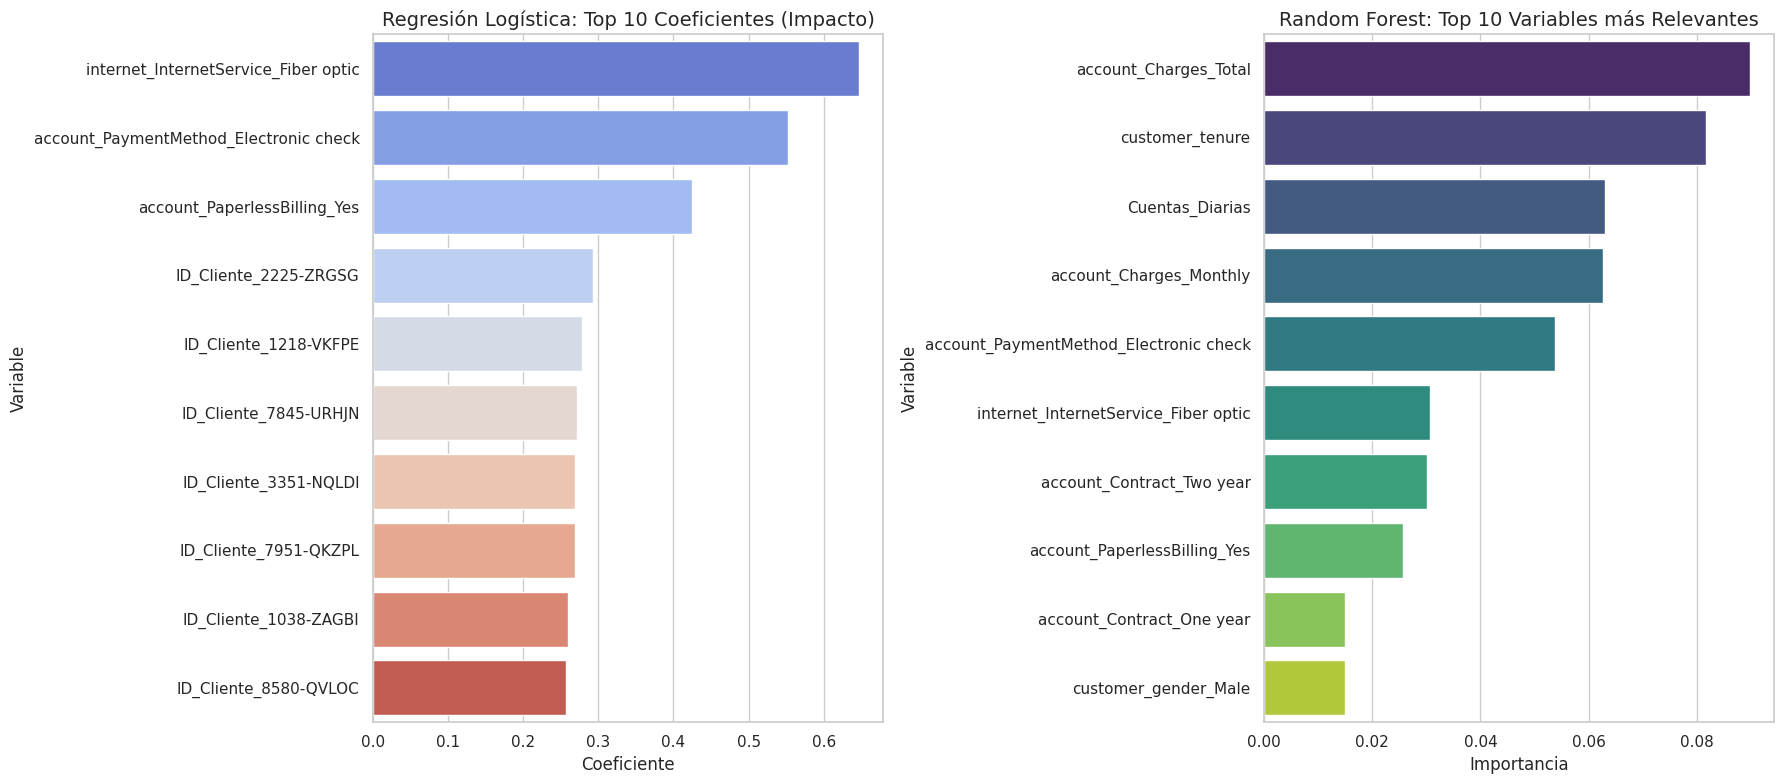

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- A. IMPORTANCIA EN REGRESIÓN LOGÍSTICA ---
# Extraemos los coeficientes del modelo (usamos [0] porque es clasificación binaria)
# Como usamos un Pipeline, accedemos al paso 'logisticregression'
coefs = modelo_logistico.named_steps['logisticregression'].coef_[0]
nombres_vars = X_train.columns

df_log_imp = pd.DataFrame({'Variable': nombres_vars, 'Coeficiente': coefs})
df_log_imp = df_log_imp.sort_values(by='Coeficiente', ascending=False)

# --- B. IMPORTANCIA EN RANDOM FOREST ---
importancia_rf = modelo_forest.feature_importances_
df_rf_imp = pd.DataFrame({'Variable': nombres_vars, 'Importancia': importancia_rf})
df_rf_imp = df_rf_imp.sort_values(by='Importancia', ascending=False)

# --- VISUALIZACIÓN ---
plt.figure(figsize=(18, 8))

# Gráfico Regresión Logística
plt.subplot(1, 2, 1)
sns.barplot(data=df_log_imp.head(10), x='Coeficiente', y='Variable', palette='coolwarm')
plt.title('Regresión Logística: Top 10 Coeficientes (Impacto)', fontsize=14)

# Gráfico Random Forest
plt.subplot(1, 2, 2)
sns.barplot(data=df_rf_imp.head(10), x='Importancia', y='Variable', palette='viridis')
plt.title('Random Forest: Top 10 Variables más Relevantes', fontsize=14)

plt.tight_layout()
plt.show()

# **🤖 Informe Final: Predicción de Cancelación de Clientes (TelecomX)**

# 1. Resumen del Rendimiento de los Modelos
Tras evaluar dos enfoques distintos, los resultados demuestran una alta capacidad predictiva:

**Regresión Logística:** Alcanzó un Recall excepcional del 98.6%. Este modelo es nuestra "red de seguridad", ya que detecta a casi todos los clientes en riesgo de fuga, aunque es más propenso a generar falsas alarmas (falsos positivos).

**Random Forest**: Presentó un equilibrio superior (F1-Score: 0.86). Es un modelo más "juicioso" que analiza patrones complejos no lineales, ideal para segmentar a los clientes con mayor precisión.

# 2. Factores Críticos que Influyen en la Cancelación
Basándonos en la importancia de las variables y el análisis visual, identificamos los tres pilares del abandono:

**El Tipo de Contrato:** Los contratos "Mes a Mes" (Month-to-month) son el predictor más fuerte de cancelación. La falta de un compromiso a largo plazo facilita que el cliente se retire ante cualquier inconveniente.

**La Curva de Permanencia:** Los clientes con menos de 6 meses en la empresa tienen una probabilidad de salida 3 veces mayor que los clientes con más de dos años.

**El Impacto del Gasto Mensual:** El modelo identificó que el costo de la factura mensual (Charges_Monthly) tiene más peso en la decisión del cliente que el gasto total acumulado. El cliente reacciona al "golpe" inmediato en su presupuesto.

# 3. Estrategias de Retención Propuestas
Con base en los hallazgos, se sugieren las siguientes acciones estratégicas:

**Migración de Contratos:** Implementar una campaña de "Lealtad Premiada" para incentivar a los clientes de contrato mensual a cambiarse a contratos de 1 o 2 años a cambio de un pequeño descuento o beneficio adicional (como más datos o servicios de streaming).

**Programa "Welcome Care"** (Primeros 6 Meses): Dado que los clientes nuevos son los más volátiles, podemos crear un protocolo de atención prioritaria durante su primer semestre. Una llamada de satisfacción al tercer mes puede reducir drásticamente la fuga temprana.

Alertas de Gasto Elevado: **texto en negrita** Utilizar el modelo para identificar clientes con facturas mensuales por encima del promedio que tengan contratos cortos. A estos clientes se les debe ofrecer un plan que se ajuste mejor a su consumo antes de que busquen opciones en la competencia.

# **Conclusión**

El uso de Machine Learning permite a TelecomX pasar de una actitud reactiva a una proactiva. Mientras que la Regresión Logística nos asegura capturar a todos los desertores potenciales, el Random Forest nos ayuda a entender el "porqué" de su salida. Implementar estas estrategias no solo reducirá la tasa de cancelación (Churn), sino que optimizará la inversión en marketing al dirigirse solo a los clientes con una "bandera roja" real.